<a href="https://colab.research.google.com/github/Priyam-1407/Hands-on-Machine_learning/blob/main/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [62]:
from sklearn.datasets import load_breast_cancer

In [63]:
data= load_breast_cancer()
df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [64]:
features = [
    'mean radius',
    'worst radius',
    'mean perimeter',
    'mean texture'
]

In [65]:
x=df[features]
y =df["target"]

In [66]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)


In [67]:
x_train.shape

(455, 4)

In [68]:
x_test.shape

(114, 4)

In [69]:
x_train

,mean radius,worst radius,mean perimeter,mean texture
555,10.29,10.840,65.67,27.61
417,15.50,23.170,102.90,21.08
499,20.59,23.860,137.80,21.24
496,12.65,14.380,82.69,18.17
65,14.78,17.310,97.40,23.94
...,...,...,...,...
455,13.38,15.050,86.34,30.72
77,18.05,22.390,120.20,16.15
568,7.76,9.456,47.92,24.54
199,14.45,18.330,94.49,20.22


In [70]:
np.round(x_train.describe(), 1)

,mean radius,worst radius,mean perimeter,mean texture
count,455.0,455.0,455.0,455.0
mean,14.3,16.5,93.1,19.4
std,3.6,5.0,25.1,4.3
min,7.7,8.7,47.9,10.4
25%,11.8,13.1,75.5,16.3
50%,13.5,15.0,87.2,18.9
75%,16.1,19.3,107.0,21.9
max,28.1,36.0,188.5,39.3


In [82]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn1 = KNeighborsClassifier(n_neighbors=5)

knn1.fit(x_train, y_train)

y_pred1 = knn1.predict(x_test)

acc1 = accuracy_score(y_test, y_pred1)

print("KNN Accuracy without scaling:", acc1)

KNN Accuracy without scaling: 0.9210526315789473


In [72]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
#fit for the training data
scaler.fit(x_train)
#transform for both testing and training data
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [73]:
scaler.mean_

array([14.29221758, 16.50924615, 93.14883516, 19.42318681])

see the difference between the x_train and x_train_scaled

In [74]:
x_train_scaled

array([[-1.1045548 , -1.13734901, -1.09647179,  1.89980063],
       [ 0.33333067,  1.33626264,  0.38909499,  0.38447375],
       [ 1.73809786,  1.47468859,  1.78168916,  0.42160274],
       ...,
       [-1.80279862, -1.41500339, -1.8047396 ,  1.18738814],
       [ 0.04354569,  0.36527477,  0.05351571,  0.18490543],
       [-0.83132897, -0.9206823 , -0.80398711, -1.40003831]])

In [75]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_train_scaled

,mean radius,worst radius,mean perimeter,mean texture
0,-1.104555,-1.137349,-1.096472,1.899801
1,0.333331,1.336263,0.389095,0.384474
2,1.738098,1.474689,1.781689,0.421603
3,-0.453229,-0.427164,-0.417333,-0.290810
4,0.134621,0.160645,0.169632,1.048154
...,...,...,...,...
450,-0.251759,-0.292750,-0.271689,2.621495
451,1.037094,1.179781,1.079407,-0.759563
452,-1.802799,-1.415003,-1.804740,1.187388
453,0.043546,0.365275,0.053516,0.184905


In [76]:
np.round(x_train_scaled.describe(), 1)

,mean radius,worst radius,mean perimeter,mean texture
count,455.0,455.0,455.0,455.0
mean,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0
min,-1.8,-1.6,-1.8,-2.1
25%,-0.7,-0.7,-0.7,-0.7
50%,-0.2,-0.3,-0.2,-0.1
75%,0.5,0.6,0.6,0.6
max,3.8,3.9,3.8,4.6


**effect of scaling**

In [77]:
features = ['mean radius', 'mean concave points']

<Axes: xlabel='mean radius', ylabel='mean concave points'>

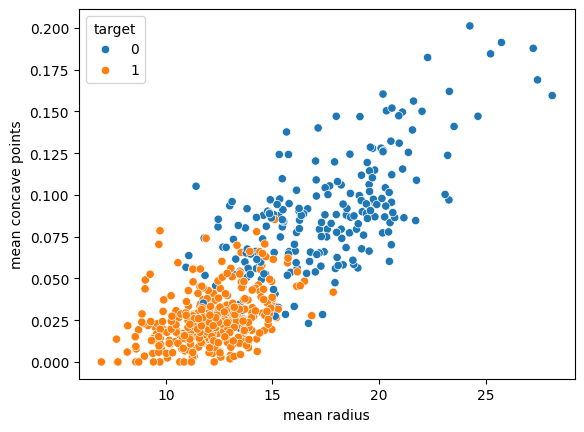

In [78]:
sns.scatterplot(
    x=df['mean radius'],
    y=df['mean concave points'],
    hue=df['target']
)

In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

import pandas as pd
scaled_df = pd.DataFrame(scaled_data, columns=features)
scaled_df['target'] = df['target']

<Axes: xlabel='mean radius', ylabel='mean concave points'>

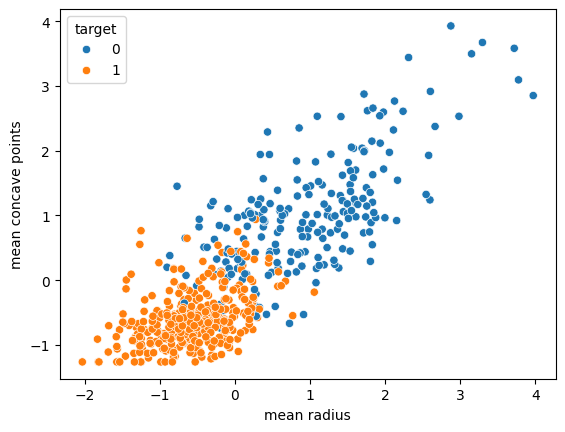

In [80]:
sns.scatterplot(
    x=scaled_df['mean radius'],
    y=scaled_df['mean concave points'],
    hue=scaled_df['target']
)

Scatter plots before and after scaling show that the overall distribution and class separation remain unchanged. However, scaling centers the data around zero and ensures equal spread across axes, making the feature space more balanced for model learning.

**why is scaling important**

In [83]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn2 = KNeighborsClassifier(n_neighbors=5)

knn2.fit(x_train_scaled, y_train)

y_pred2 = knn2.predict(x_test_scaled)

acc2 = accuracy_score(y_test, y_pred2)

print("KNN Accuracy with scaling:", acc2)

KNN Accuracy with scaling: 0.9298245614035088


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Effect of Feature Scaling on Models

Feature scaling was applied using Standardization to ensure that all features have zero mean and unit variance.

### KNN (K-Nearest Neighbors)

KNN is a distance-based algorithm, so scaling plays a crucial role in its performance. Without scaling, features with larger magnitudes dominate the distance calculation, leading to incorrect neighbor selection. After applying scaling, all features contribute equally, resulting in improved accuracy.

### Logistic Regression

Logistic Regression is not directly dependent on distance calculations. Therefore, scaling does not significantly impact its accuracy. In this case, the performance remained almost the same, with a slight decrease due to changes in optimization during training.

### Conclusion

Feature scaling is essential for distance-based models like KNN, where it significantly improves performance. However, for models like Logistic Regression, scaling may not lead to noticeable accuracy improvements but still ensures stable and consistent learning.

### Key Insight

Scaling does not always increase accuracy, but it ensures that the model learns in a balanced and unbiased way.
